In [3]:
import os

path = r"C:\Users\rakhi\Downloads\Main Project\code\Yolov8Dataset\train\images"

crowd_imgs = os.listdir(path)




In [9]:

print("Total images in the dataset:", len(crowd_imgs))

Total images in the dataset: 4681


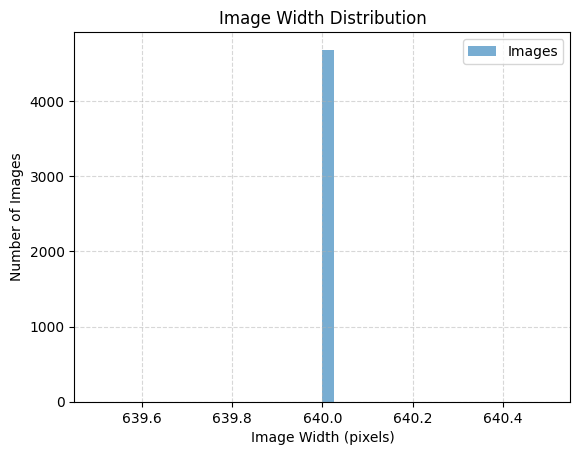

In [8]:
import os
import cv2
import matplotlib.pyplot as plt

def get_image_sizes(folder):
    sizes = []
    for img_name in os.listdir(folder):
        img = cv2.imread(os.path.join(folder, img_name))
        if img is not None:
            h, w, _ = img.shape
            sizes.append((w, h))
    return sizes

crowd_sizes = get_image_sizes(path)

cw, ch = zip(*crowd_sizes)

plt.hist(cw, bins=40, alpha=0.6, label="Images")

plt.xlabel("Image Width (pixels)")          
plt.ylabel("Number of Images")               
plt.title("Image Width Distribution")

plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


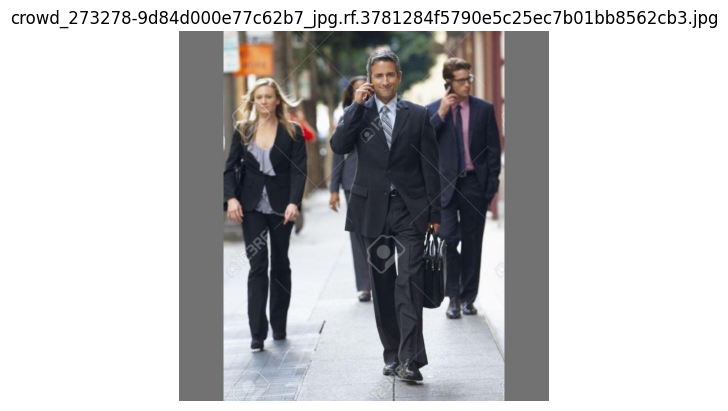

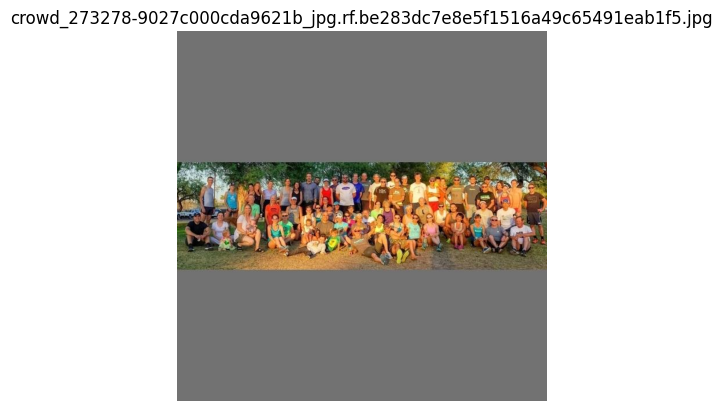

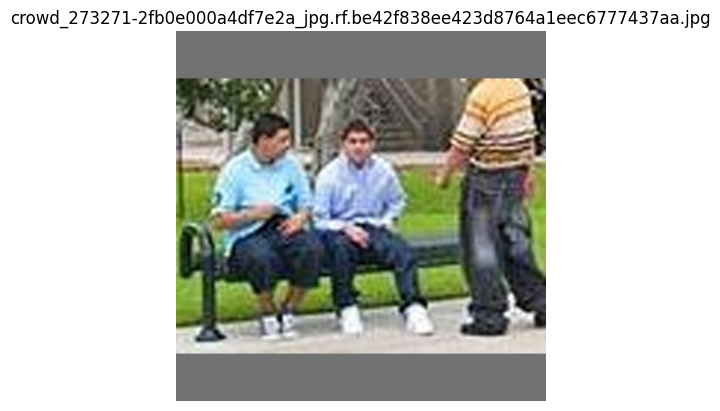

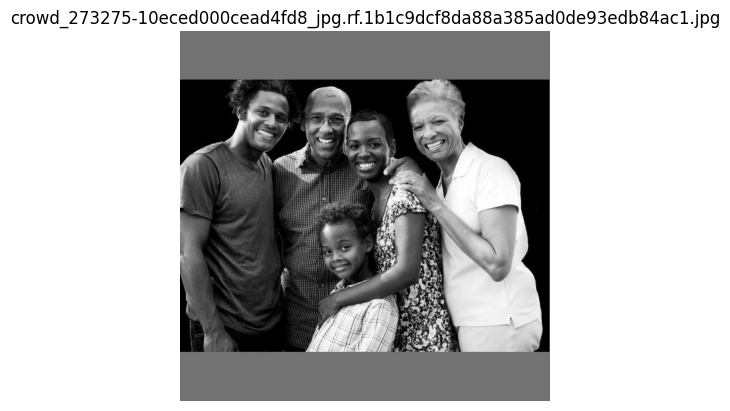

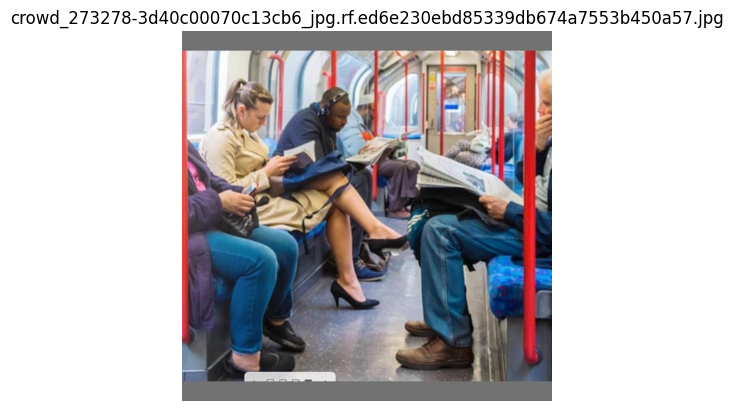

In [6]:
import random
from matplotlib import pyplot as plt

def show_random_images(folder, n=5):
    imgs = random.sample(os.listdir(folder), n)
    for img_name in imgs:
        img = cv2.imread(os.path.join(folder, img_name))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img)
        plt.title(img_name)
        plt.axis("off")
        plt.show()

show_random_images(path)


In [7]:
def analyze_folder(folder_path):
    image_shapes = []
    corrupt = 0

    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)
        img = cv2.imread(img_path)
        if img is None:
            corrupt += 1
            continue
        h, w, _ = img.shape
        image_shapes.append((w, h))

    return image_shapes, corrupt

crowd_shapes, crowd_corrupt = analyze_folder(path)

print("\n Dataset Overview")
print("-" * 40)
print(f"CROWD Images     : {len(crowd_shapes)}")
print(f"Corrupted Images : {crowd_corrupt}")
print("-" * 40)



 Dataset Overview
----------------------------------------
CROWD Images     : 4681
Corrupted Images : 0
----------------------------------------


In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))


True
NVIDIA GeForce GTX 1650


In [ ]:
import os
import shutil
import random
from pathlib import Path

# ─────────────────────────────────────────
# CONFIGURE THESE TO MATCH YOUR SETUP
# ─────────────────────────────────────────
SOURCE_IMAGES_DIR = r"C:\Users\rakhi\Downloads\Main Project\code\Yolov8Dataset\train\images"
SOURCE_LABELS_DIR = r"C:\Users\rakhi\Downloads\Main Project\code\Yolov8Dataset\train\labels"
OUTPUT_DIR        = r"C:\Users\rakhi\Downloads\Main Project\code\human_dataset" # output folder
CLASS_NAMES       = ["person"]      # change if you have more classes
TRAIN_RATIO       = 0.70
VAL_RATIO         = 0.20
TEST_RATIO        = 0.10
SEED              = 42
# ─────────────────────────────────────────

def split_dataset():
    random.seed(SEED)

    # Grab all images
    image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    images = [
        f for f in Path(SOURCE_IMAGES_DIR).iterdir()
        if f.suffix.lower() in image_extensions
    ]

    # Only keep images that have a matching label file
    images = [
        img for img in images
        if (Path(SOURCE_LABELS_DIR) / img.with_suffix(".txt").name).exists()
    ]

    random.shuffle(images)

    total  = len(images)
    n_train = int(total * TRAIN_RATIO)
    n_val   = int(total * VAL_RATIO)

    splits = {
        "train": images[:n_train],
        "val":   images[n_train:n_train + n_val],
        "test":  images[n_train + n_val:]
    }

    print(f"Total paired samples : {total}")
    print(f"  Train : {len(splits['train'])}")
    print(f"  Val   : {len(splits['val'])}")
    print(f"  Test  : {len(splits['test'])}")

    # Create output folder structure
    for split in splits:
        Path(f"{OUTPUT_DIR}/{split}/images").mkdir(parents=True, exist_ok=True)
        Path(f"{OUTPUT_DIR}/{split}/labels").mkdir(parents=True, exist_ok=True)

    # Copy files
    for split, files in splits.items():
        for img_path in files:
            lbl_path = Path(SOURCE_LABELS_DIR) / img_path.with_suffix(".txt").name

            shutil.copy(img_path, f"{OUTPUT_DIR}/{split}/images/{img_path.name}")
            shutil.copy(lbl_path, f"{OUTPUT_DIR}/{split}/labels/{lbl_path.name}")

    print("\n✅ Dataset split complete!")


def create_yaml():
    abs_path = str(Path(OUTPUT_DIR).resolve())

    yaml_content = f"""# Human Detection Dataset - YOLOv8
path: {abs_path}

train: train/images
val:   val/images
test:  test/images

nc: {len(CLASS_NAMES)}
names: {CLASS_NAMES}
"""

    yaml_path = Path(OUTPUT_DIR) / "dataset.yaml"
    with open(yaml_path, "w") as f:
        f.write(yaml_content)

    print(f"✅ YAML file saved → {yaml_path}")
    print("\n📄 YAML Preview:")
    print(yaml_content)


if __name__ == "__main__":
    split_dataset()
    create_yaml()

Total paired samples : 4681
  Train : 3276
  Val   : 936
  Test  : 469

✅ Dataset split complete!
✅ YAML file saved → C:\Users\rakhi\Downloads\Main Project\code\human_dataset\dataset.yaml

📄 YAML Preview:
# Human Detection Dataset - YOLOv8
path: C:\Users\rakhi\Downloads\Main Project\code\human_dataset

train: train/images
val:   val/images
test:  test/images

nc: 1
names: ['person']



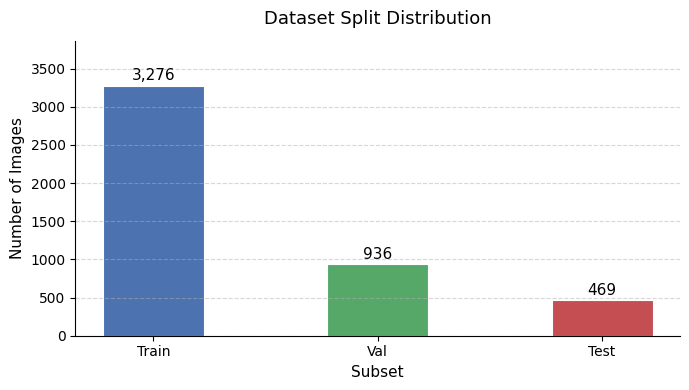

✅ split_distribution.png saved


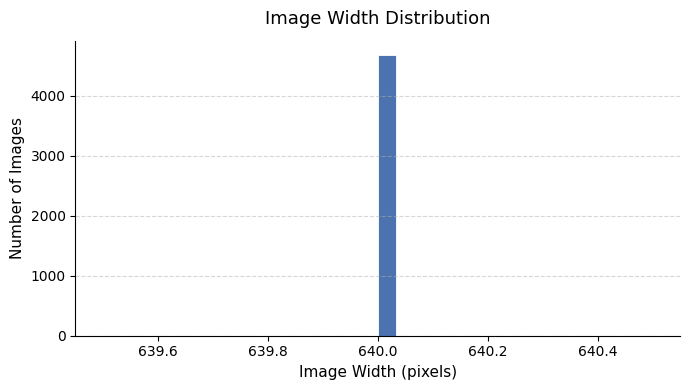

✅ ImageWidth.png saved


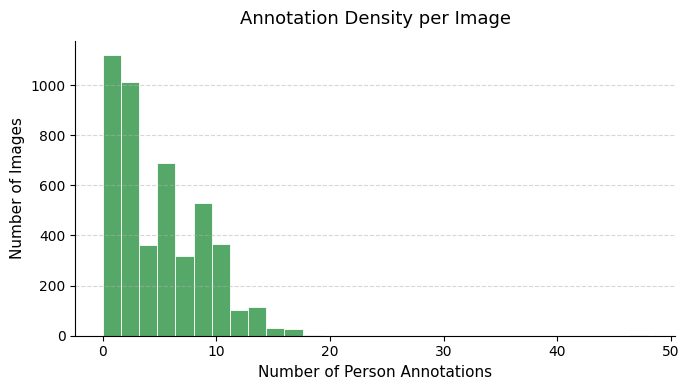

✅ annotation_density.png saved


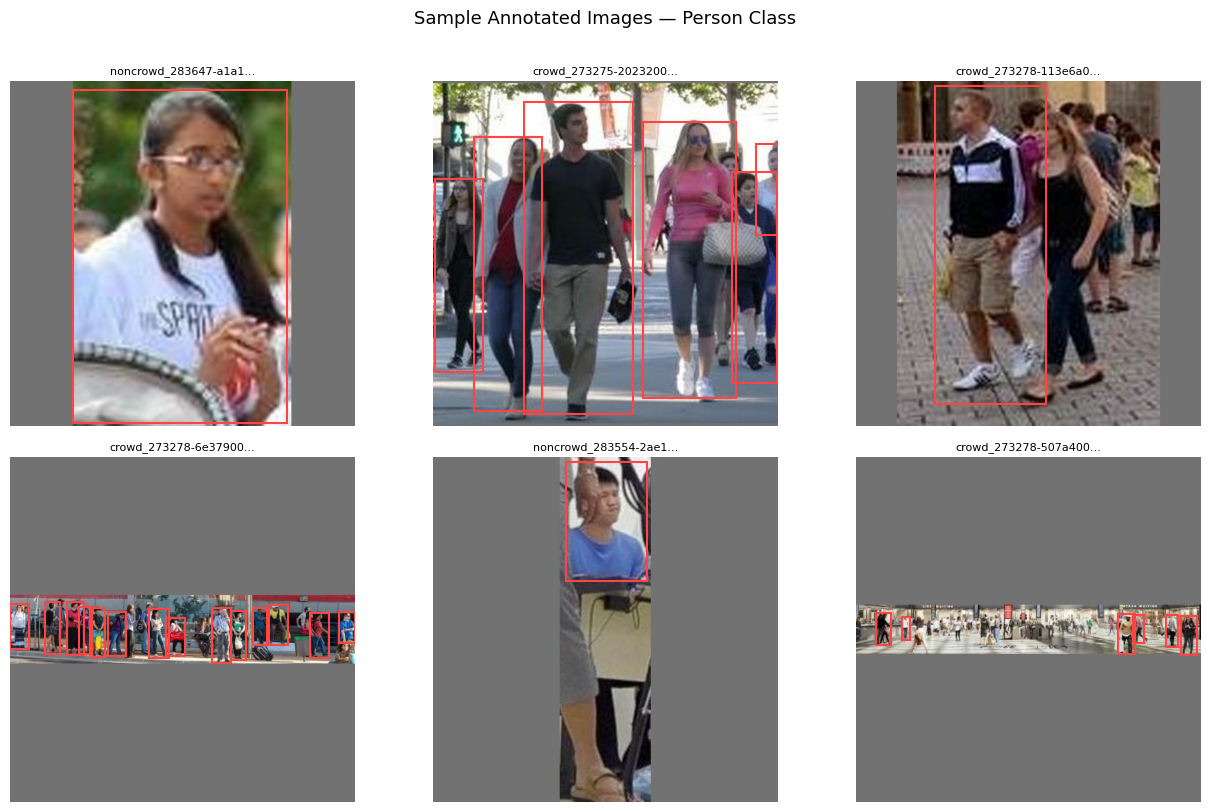

✅ sample_annotations.png saved

✅ All visualizations saved to: C:\Users\rakhi\Downloads\Main Project\report_images


In [10]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path

# ── paths ──────────────────────────────────────────────────────────────
BASE_DIR   = r"C:\Users\rakhi\Downloads\Main Project\code\human_dataset"
SPLITS     = {"Train": "train", "Val": "val", "Test": "test"}
SAVE_DIR   = r"C:\Users\rakhi\Downloads\Main Project\report_images"
os.makedirs(SAVE_DIR, exist_ok=True)


# ── 1. SPLIT DISTRIBUTION BAR CHART ────────────────────────────────────
split_counts = {"Train": 3276, "Val": 936, "Test": 469}
colors       = ["#4C72B0", "#55A868", "#C44E52"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(split_counts.keys(), split_counts.values(),
              color=colors, width=0.45, edgecolor="white", linewidth=0.8)

for bar, val in zip(bars, split_counts.values()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 30,
            f"{val:,}", ha="center", va="bottom", fontsize=11)

ax.set_title("Dataset Split Distribution", fontsize=13, pad=12)
ax.set_ylabel("Number of Images", fontsize=11)
ax.set_xlabel("Subset", fontsize=11)
ax.set_ylim(0, max(split_counts.values()) * 1.18)
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "split_distribution.png"), dpi=150)
plt.show()
print("✅ split_distribution.png saved")


# ── 2. IMAGE WIDTH DISTRIBUTION ─────────────────────────────────────────
widths = []
for split in SPLITS.values():
    img_dir = os.path.join(BASE_DIR, split, "images")
    for f in Path(img_dir).glob("*.*"):
        img = cv2.imread(str(f))
        if img is not None:
            widths.append(img.shape[1])

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(widths, bins=30, color="#4C72B0", edgecolor="white", linewidth=0.6)
ax.set_title("Image Width Distribution", fontsize=13, pad=12)
ax.set_xlabel("Image Width (pixels)", fontsize=11)
ax.set_ylabel("Number of Images", fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "ImageWidth.png"), dpi=150)
plt.show()
print("✅ ImageWidth.png saved")


# ── 3. ANNOTATION DENSITY DISTRIBUTION ──────────────────────────────────
annotation_counts = []
for split in SPLITS.values():
    lbl_dir = os.path.join(BASE_DIR, split, "labels")
    for f in Path(lbl_dir).glob("*.txt"):
        with open(f, "r") as fp:
            lines = [l.strip() for l in fp if l.strip()]
        annotation_counts.append(len(lines))

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(annotation_counts, bins=30, color="#55A868",
        edgecolor="white", linewidth=0.6)
ax.set_title("Annotation Density per Image", fontsize=13, pad=12)
ax.set_xlabel("Number of Person Annotations", fontsize=11)
ax.set_ylabel("Number of Images", fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "annotation_density.png"), dpi=150)
plt.show()
print("✅ annotation_density.png saved")


# ── 4. SAMPLE ANNOTATED IMAGES ───────────────────────────────────────────
def draw_yolo_boxes(img_path, label_path):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    fig, ax = plt.subplots(1, figsize=(4, 4))
    ax.imshow(img)

    if os.path.exists(label_path):
        with open(label_path, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                _, cx, cy, bw, bh = map(float, parts[:5])
                x1 = (cx - bw / 2) * w
                y1 = (cy - bh / 2) * h
                rect = patches.Rectangle(
                    (x1, y1), bw * w, bh * h,
                    linewidth=1.5, edgecolor="#FF4444",
                    facecolor="none"
                )
                ax.add_patch(rect)

    ax.axis("off")
    return fig


# collect 6 random samples from train set
train_img_dir = os.path.join(BASE_DIR, "train", "images")
train_lbl_dir = os.path.join(BASE_DIR, "train", "labels")
all_imgs      = list(Path(train_img_dir).glob("*.*"))
samples       = random.sample(all_imgs, min(6, len(all_imgs)))

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.flatten()

for ax, img_path in zip(axes, samples):
    lbl_path = os.path.join(
        train_lbl_dir,
        img_path.stem + ".txt"
    )
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    ax.imshow(img)

    if os.path.exists(lbl_path):
        with open(lbl_path, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                _, cx, cy, bw, bh = map(float, parts[:5])
                x1 = (cx - bw / 2) * w
                y1 = (cy - bh / 2) * h
                rect = patches.Rectangle(
                    (x1, y1), bw * w, bh * h,
                    linewidth=1.5, edgecolor="#FF4444",
                    facecolor="none"
                )
                ax.add_patch(rect)

    ax.set_title(f"{img_path.name[:20]}...", fontsize=8)
    ax.axis("off")

plt.suptitle("Sample Annotated Images — Person Class",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "sample_annotations.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ sample_annotations.png saved")

print("\n✅ All visualizations saved to:", SAVE_DIR)

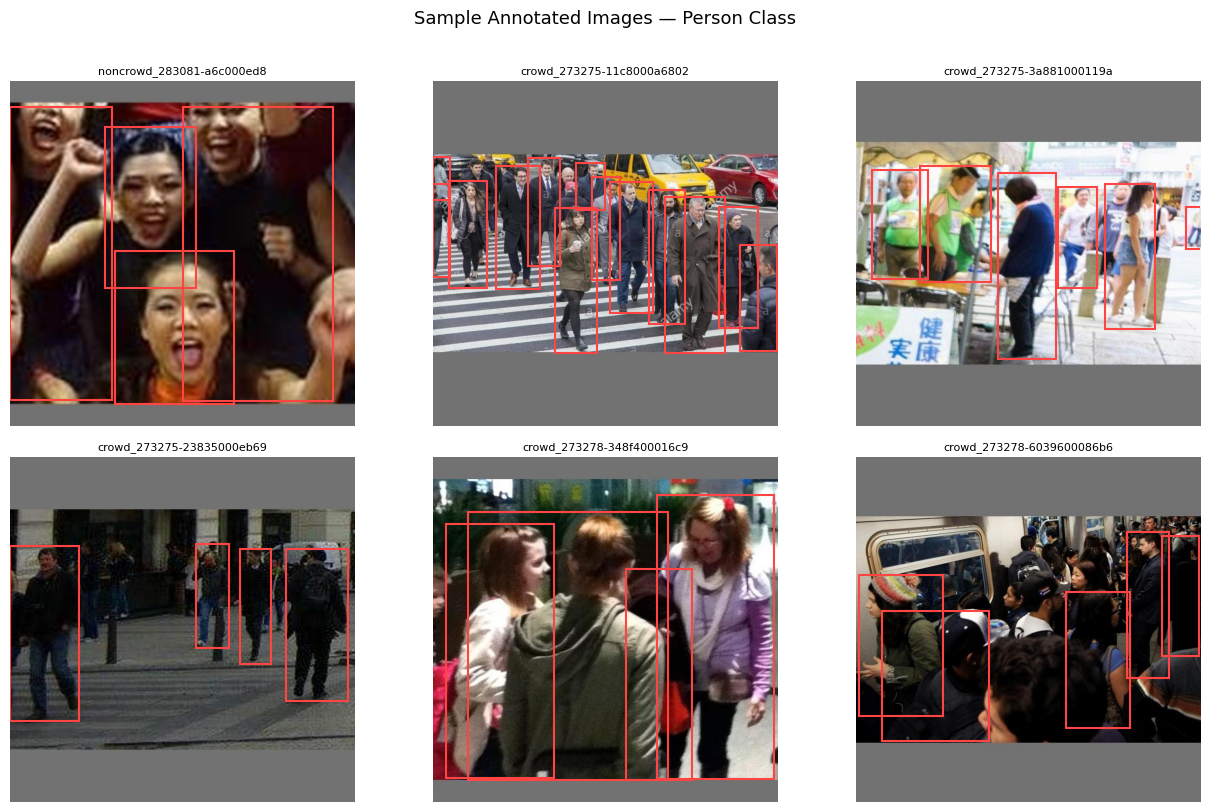

✅ sample_annotations.png saved to: C:\Users\rakhi\Downloads\Main Project\report_images


In [18]:
import os
import cv2
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path

# ── paths ──────────────────────────────────────────────────────────────
BASE_DIR     = r"C:\Users\rakhi\Downloads\Main Project\code\human_dataset"
SAVE_DIR     = r"C:\Users\rakhi\Downloads\Main Project\report_images"
os.makedirs(SAVE_DIR, exist_ok=True)

train_img_dir = os.path.join(BASE_DIR, "train", "images")
train_lbl_dir = os.path.join(BASE_DIR, "train", "labels")

# ── collect 6 random samples ───────────────────────────────────────────
all_imgs = list(Path(train_img_dir).glob("*.*"))
samples  = random.sample(all_imgs, min(6, len(all_imgs)))

# ── plot ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.flatten()

for ax, img_path in zip(axes, samples):
    lbl_path = os.path.join(train_lbl_dir, img_path.stem + ".txt")

    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    ax.imshow(img)

    if os.path.exists(lbl_path):
        with open(lbl_path, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                _, cx, cy, bw, bh = map(float, parts[:5])
                x1 = (cx - bw / 2) * w
                y1 = (cy - bh / 2) * h
                rect = patches.Rectangle(
                    (x1, y1), bw * w, bh * h,
                    linewidth=1.5,
                    edgecolor="#FF4444",
                    facecolor="none"
                )
                ax.add_patch(rect)

    ax.set_title(f"{img_path.name[:25]}", fontsize=8)
    ax.axis("off")

plt.suptitle("Sample Annotated Images — Person Class",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "sample_annotations.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ sample_annotations.png saved to:", SAVE_DIR)

In [ ]:
import os
from pathlib import Path
from ultralytics import YOLO
import torch

# ─────────────────────────────────────────
# CONFIGURE THESE
# ─────────────────────────────────────────
DATASET_YAML  = "human_dataset/dataset.yaml"
MODEL         = "yolov8s.pt"          # yolov8s = small, good balance of speed/accuracy
EPOCHS        = 50
IMG_SIZE      = 640
BATCH_SIZE    = 16                    # lower to 8 if you get OOM errors
PROJECT_NAME  = "human_detection"
RUN_NAME      = "yolov8s_run1"
DEVICE        = 0 if torch.cuda.is_available() else "cpu"
# ─────────────────────────────────────────


def train():
    print(f"\n🚀 Training on: {'GPU - ' + torch.cuda.get_device_name(0) if DEVICE == 0 else 'CPU'}")
    print(f"📦 Model       : {MODEL}")
    print(f"📁 Dataset     : {DATASET_YAML}")
    print(f"🔁 Epochs      : {EPOCHS}\n")

    model = YOLO(MODEL)

    results = model.train(
        data        = DATASET_YAML,
        epochs      = EPOCHS,
        imgsz       = IMG_SIZE,
        batch       = BATCH_SIZE,
        device      = DEVICE,
        project     = PROJECT_NAME,
        name        = RUN_NAME,
        workers     = 4,
        patience    = 15,           # early stopping if no improvement for 15 epochs
        save        = True,
        save_period = 10,           # save checkpoint every 10 epochs
        exist_ok    = True,
        pretrained  = True,
        optimizer   = "AdamW",
        lr0         = 0.001,
        momentum    = 0.937,
        weight_decay= 0.0005,
        augment     = True,
        verbose     = True,
    )

    print("\n✅ Training complete!")
    print(f"📂 Results saved to → {PROJECT_NAME}/{RUN_NAME}")
    return model


def evaluate(model=None):
    # If no model passed in, load the best weights from training
    best_weights = Path(PROJECT_NAME) / RUN_NAME / "weights" / "best.pt"

    if model is None:
        print(f"\n📥 Loading best weights from: {best_weights}")
        model = YOLO(str(best_weights))

    print("\n📊 Running Evaluation on Validation Set...")
    val_results = model.val(
        data    = DATASET_YAML,
        imgsz   = IMG_SIZE,
        batch   = BATCH_SIZE,
        device  = DEVICE,
        split   = "val",            # change to "test" to eval on test set
        verbose = True,
        project = PROJECT_NAME,
        name    = RUN_NAME + "_val_eval",
        exist_ok= True,
    )

    print("\n📊 Running Evaluation on Test Set...")
    test_results = model.val(
        data    = DATASET_YAML,
        imgsz   = IMG_SIZE,
        batch   = BATCH_SIZE,
        device  = DEVICE,
        split   = "test",
        verbose = True,
        project = PROJECT_NAME,
        name    = RUN_NAME + "_test_eval",
        exist_ok= True,
    )

    print_metrics(val_results,  label="VALIDATION")
    print_metrics(test_results, label="TEST")


def print_metrics(results, label=""):
    print(f"\n{'='*45}")
    print(f"  📈 {label} METRICS")
    print(f"{'='*45}")
    print(f"  Precision  (P)  : {results.results_dict.get('metrics/precision(B)', 0):.4f}")
    print(f"  Recall     (R)  : {results.results_dict.get('metrics/recall(B)', 0):.4f}")
    print(f"  mAP@0.5         : {results.results_dict.get('metrics/mAP50(B)', 0):.4f}")
    print(f"  mAP@0.5:0.95    : {results.results_dict.get('metrics/mAP50-95(B)', 0):.4f}")
    print(f"  Fitness Score   : {results.results_dict.get('fitness', 0):.4f}")
    print(f"{'='*45}\n")


if __name__ == "__main__":
    # Train then immediately evaluate
    trained_model = train()
    evaluate(trained_model)
# ```

# ---

# **Quick breakdown of what you get:**

# **Training goodies:**
# - Loads pretrained `yolov8s.pt` weights (transfer learning)
# - Early stopping with patience of 15 epochs so it doesn't overfit
# - AdamW optimizer with solid default hyperparameters
# - Saves best + last checkpoints automatically
# - All logs, curves, and weights go into `human_detection/yolov8s_run1/`

# **Evaluation metrics printed:**
# - **Precision** — of all detections, how many were actually humans
# - **Recall** — of all actual humans, how many were detected
# - **mAP@0.5** — main detection accuracy metric
# - **mAP@0.5:0.95** — stricter overall accuracy
# - **Fitness Score** — YOLOv8's combined metric

# **After training your results folder will have:**
# ```
# human_detection/yolov8s_run1/
# ├── weights/
# │   ├── best.pt       ← use this for inference
# │   └── last.pt
# ├── results.csv
# ├── confusion_matrix.png
# ├── PR_curve.png
# ├── F1_curve.png
# └── results.png       ← all training curves in one image

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\rakhi\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

🚀 Training on: GPU - NVIDIA GeForce GTX 1650
📦 Model       : yolov8s.pt
📁 Dataset     : human_dataset/dataset.yaml
🔁 Epochs      : 50

Ultralytics 8.4.14  Python-3.10.7 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce GTX 1650, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=human_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, eras